In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [2]:
np.random.seed(42)
torch.manual_seed(42)

In [3]:
# 时间步
t = np.arange(0, 300)

# 构造时间序列：趋势 + 周期 + 噪声
series = 0.03 * t + np.sin(0.2 * t) + 0.3 * np.random.randn(len(t))

print("前 10 个数据：")
print(series[:10])

print("序列长度：", len(series))

前 10 个数据：
[0.14901425 0.18719004 0.6437249  1.11155143 0.76711008 0.9212299
 1.58580293 1.42568015 1.09873129 1.40661564]
序列长度： 300


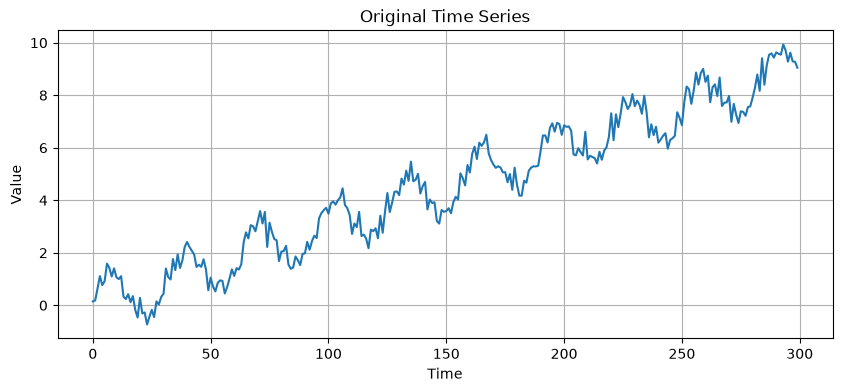

In [4]:
plt.figure(figsize=(10, 4))
plt.plot(t, series)
plt.title("Original Time Series")
plt.xlabel("Time")
plt.ylabel("Value")
plt.grid(True)
plt.show()

In [5]:
def create_sequences(series, window_size):
    X = []
    y = []

    for i in range(len(series) - window_size):
        X.append(series[i:i + window_size])
        y.append(series[i + window_size])

    return np.array(X), np.array(y)

In [6]:
window_size = 10

X, y = create_sequences(series, window_size)

print("X shape:", X.shape)
print("y shape:", y.shape)

print("第一个输入样本：")
print(X[0])

print("第一个标签：")
print(y[0])

X shape: (290, 10)
y shape: (290,)
第一个输入样本：
[0.14901425 0.18719004 0.6437249  1.11155143 0.76711008 0.9212299
 1.58580293 1.42568015 1.09873129 1.40661564]
第一个标签：
1.070272118981943


In [7]:
X = X.reshape(X.shape[0], X.shape[1], 1)

print("调整后的 X shape:", X.shape)

调整后的 X shape: (290, 10, 1)


In [8]:
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
y_train = y[:train_size]

X_test = X[train_size:]
y_test = y[train_size:]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (232, 10, 1)
y_train: (232,)
X_test: (58, 10, 1)
y_test: (58,)


In [9]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

print("X_train_tensor:", X_train_tensor.shape)
print("y_train_tensor:", y_train_tensor.shape)

X_train_tensor: torch.Size([232, 10, 1])
y_train_tensor: torch.Size([232, 1])


In [10]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [11]:
train_dataset = TimeSeriesDataset(X_train_tensor, y_train_tensor)
test_dataset = TimeSeriesDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False
)

In [12]:
class GRUForecaster(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers):
        super().__init__()

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x shape:
        # (batch_size, sequence_length, input_size)

        out, h_n = self.gru(x)

        # out shape:
        # (batch_size, sequence_length, hidden_size)

        # h_n shape:
        # (num_layers, batch_size, hidden_size)

        # 取最后一个时间步的输出
        last_out = out[:, -1, :]

        # last_out shape:
        # (batch_size, hidden_size)

        pred = self.fc(last_out)

        return pred

In [13]:
input_size = 1
hidden_size = 32
num_layers = 1

model = GRUForecaster(
    input_size=input_size,
    hidden_size=hidden_size,
    num_layers=num_layers
)

print(model)

GRUForecaster(
  (gru): GRU(1, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


In [14]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [15]:
epochs = 100

train_losses = []

for epoch in range(epochs):
    model.train()

    epoch_loss = 0

    for batch_X, batch_y in train_loader:
        # 前向传播
        pred = model(batch_X)

        # 计算损失
        loss = criterion(pred, batch_y)

        # 清空梯度
        optimizer.zero_grad()

        # 反向传播
        loss.backward()

        # 更新参数
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")

Epoch [10/100], Loss: 0.2444
Epoch [20/100], Loss: 0.1881
Epoch [30/100], Loss: 0.2061
Epoch [40/100], Loss: 0.2120
Epoch [50/100], Loss: 0.2631
Epoch [60/100], Loss: 0.2328
Epoch [70/100], Loss: 0.2492
Epoch [80/100], Loss: 0.3019
Epoch [90/100], Loss: 0.2582
Epoch [100/100], Loss: 0.2715


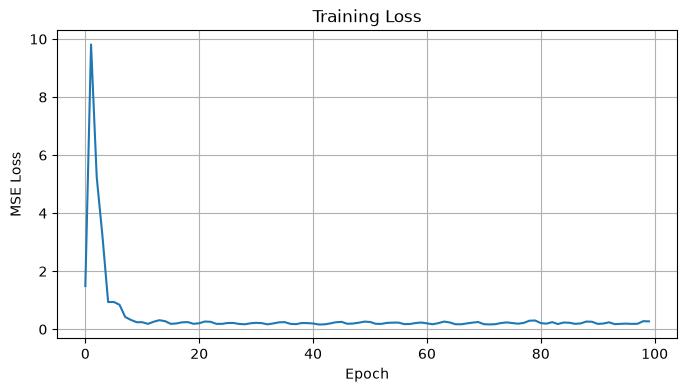

In [16]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()

In [17]:
model.eval()

with torch.no_grad():
    y_pred = model(X_test_tensor)

print("预测结果 shape:", y_pred.shape)
print("真实结果 shape:", y_test_tensor.shape)

预测结果 shape: torch.Size([58, 1])
真实结果 shape: torch.Size([58, 1])


In [18]:
y_pred_np = y_pred.numpy().flatten()
y_test_np = y_test_tensor.numpy().flatten()

print("前 10 个预测值：")
print(y_pred_np[:10])

print("前 10 个真实值：")
print(y_test_np[:10])

前 10 个预测值：
[6.1681466 6.2095327 6.290855  6.0069346 6.047069  6.102487  6.1922655
 6.592723  6.7692785 6.7618084]
前 10 个真实值：
[6.4546027 6.554206  5.9654512 6.295897  6.362494  6.4525933 7.3521976
 7.1426406 6.8593597 7.739923 ]


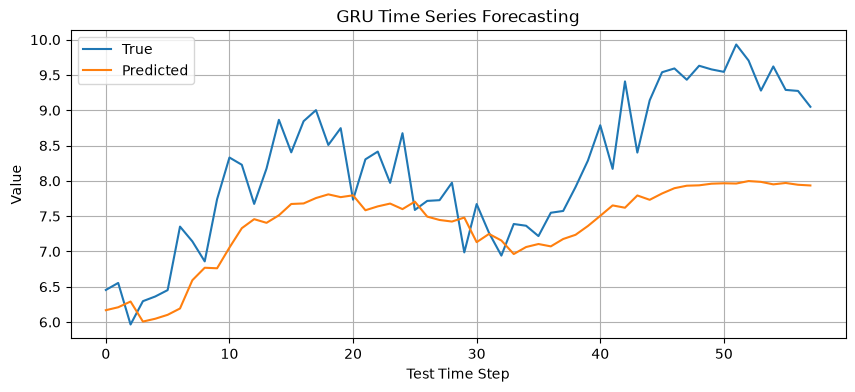

In [19]:
plt.figure(figsize=(10, 4))
plt.plot(y_test_np, label="True")
plt.plot(y_pred_np, label="Predicted")
plt.title("GRU Time Series Forecasting")
plt.xlabel("Test Time Step")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()

In [20]:
mse = np.mean((y_test_np - y_pred_np) ** 2)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(y_test_np - y_pred_np))

print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)

MSE: 0.99872255
RMSE: 0.9993611
MAE: 0.83639324


In [21]:
last_window = series[-window_size:]

print("最后 10 个时间点：")
print(last_window)

最后 10 个时间点：
[9.63043597 9.57885846 9.54409777 9.93162795 9.70434028 9.27886513
 9.62073561 9.28839162 9.27399655 9.0493692 ]


In [22]:
last_window_tensor = torch.tensor(
    last_window.reshape(1, window_size, 1),
    dtype=torch.float32
)

print("last_window_tensor shape:", last_window_tensor.shape)

last_window_tensor shape: torch.Size([1, 10, 1])


In [23]:
model.eval()

with torch.no_grad():
    next_pred = model(last_window_tensor)

print("预测下一个时间点的值：", next_pred.item())

预测下一个时间点的值： 7.906999588012695


In [24]:
hidden_sizes = [8, 16, 32, 64]

for hs in hidden_sizes:
    temp_model = GRUForecaster(
        input_size=1,
        hidden_size=hs,
        num_layers=1
    )

    temp_criterion = nn.MSELoss()
    temp_optimizer = torch.optim.Adam(temp_model.parameters(), lr=0.01)

    for epoch in range(50):
        temp_model.train()

        for batch_X, batch_y in train_loader:
            pred = temp_model(batch_X)
            loss = temp_criterion(pred, batch_y)

            temp_optimizer.zero_grad()
            loss.backward()
            temp_optimizer.step()

    temp_model.eval()

    with torch.no_grad():
        temp_pred = temp_model(X_test_tensor)

    temp_pred_np = temp_pred.numpy().flatten()
    temp_mse = np.mean((y_test_np - temp_pred_np) ** 2)

    print(f"hidden_size = {hs}, Test MSE = {temp_mse:.4f}")

hidden_size = 8, Test MSE = 1.2305
hidden_size = 16, Test MSE = 1.0965
hidden_size = 32, Test MSE = 0.5819
hidden_size = 64, Test MSE = 1.0170


In [25]:
num_layers_list = [1, 2, 3]

for nl in num_layers_list:
    temp_model = GRUForecaster(
        input_size=1,
        hidden_size=32,
        num_layers=nl
    )

    temp_criterion = nn.MSELoss()
    temp_optimizer = torch.optim.Adam(temp_model.parameters(), lr=0.01)

    for epoch in range(50):
        temp_model.train()

        for batch_X, batch_y in train_loader:
            pred = temp_model(batch_X)
            loss = temp_criterion(pred, batch_y)

            temp_optimizer.zero_grad()
            loss.backward()
            temp_optimizer.step()

    temp_model.eval()

    with torch.no_grad():
        temp_pred = temp_model(X_test_tensor)

    temp_pred_np = temp_pred.numpy().flatten()
    temp_mse = np.mean((y_test_np - temp_pred_np) ** 2)

    print(f"num_layers = {nl}, Test MSE = {temp_mse:.4f}")

num_layers = 1, Test MSE = 0.8352
num_layers = 2, Test MSE = 1.7013
num_layers = 3, Test MSE = 2.2784


In [26]:
class RNNForecaster(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers):
        super().__init__()

        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, h_n = self.rnn(x)
        last_out = out[:, -1, :]
        pred = self.fc(last_out)
        return pred


class LSTMForecaster(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        last_out = out[:, -1, :]
        pred = self.fc(last_out)
        return pred

In [27]:
def train_and_evaluate(model, train_loader, X_test_tensor, y_test_np, epochs=50):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

    for epoch in range(epochs):
        model.train()

        for batch_X, batch_y in train_loader:
            pred = model(batch_X)
            loss = criterion(pred, batch_y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    model.eval()

    with torch.no_grad():
        pred = model(X_test_tensor)

    pred_np = pred.numpy().flatten()
    mse = np.mean((y_test_np - pred_np) ** 2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(y_test_np - pred_np))

    return mse, rmse, mae, pred_np

In [28]:
models = {
    "RNN": RNNForecaster(input_size=1, hidden_size=32, num_layers=1),
    "LSTM": LSTMForecaster(input_size=1, hidden_size=32, num_layers=1),
    "GRU": GRUForecaster(input_size=1, hidden_size=32, num_layers=1)
}

results = {}

for name, temp_model in models.items():
    mse, rmse, mae, pred_np = train_and_evaluate(
        temp_model,
        train_loader,
        X_test_tensor,
        y_test_np,
        epochs=50
    )

    results[name] = {
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "Prediction": pred_np
    }

    print(f"{name} - MSE: {mse:.4f}, RMSE: {rmse:.4f}, MAE: {mae:.4f}")

RNN - MSE: 1.7687, RMSE: 1.3299, MAE: 1.1362
LSTM - MSE: 1.2008, RMSE: 1.0958, MAE: 0.8740
GRU - MSE: 0.9278, RMSE: 0.9632, MAE: 0.7667


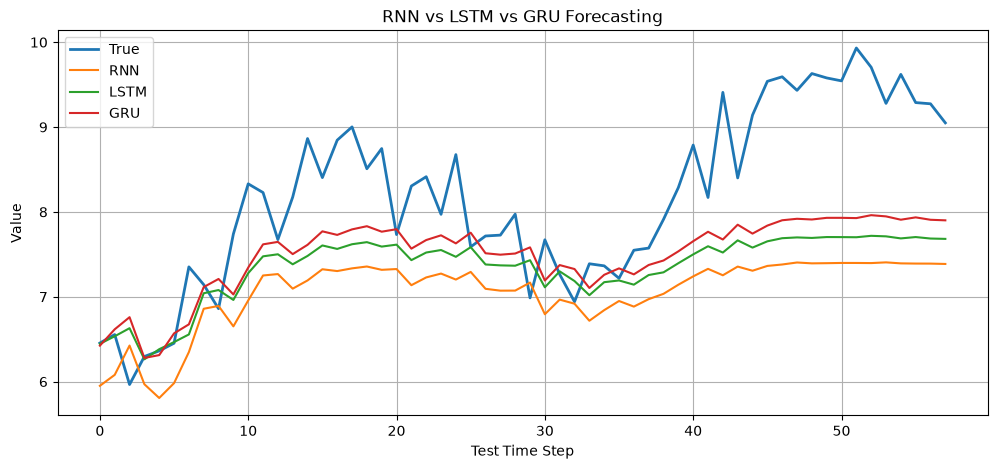

In [29]:
plt.figure(figsize=(12, 5))

plt.plot(y_test_np, label="True", linewidth=2)

for name in results:
    plt.plot(results[name]["Prediction"], label=name)

plt.title("RNN vs LSTM vs GRU Forecasting")
plt.xlabel("Test Time Step")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()